<a href="https://colab.research.google.com/github/m22aie202/FM_GenAI/blob/main/m22aie202_Assignment_1_Attempt_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
#Imports
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

import torchvision
from torchvision import transforms
from torchvision.utils import make_grid

import matplotlib.pyplot as plt
import numpy as np

In [38]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [39]:
#Loading dataset CIFAR-10
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

train_loader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

In [40]:
#Encoder
class Encoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1),   # 16
            nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), # 8
            nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1),# 4
            nn.ReLU(),
        )

        self.flatten_dim = 256 * 4 * 4
        self.fc_mu = nn.Linear(self.flatten_dim, latent_dim)
        self.fc_logvar = nn.Linear(self.flatten_dim, latent_dim)

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc_mu(x), self.fc_logvar(x)

In [41]:
#Reparameterization
def reparameterize(mu, logvar):
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    return mu + eps * std

In [42]:
#decoder same as per encoder

class Decoder(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()

        self.fc = nn.Linear(latent_dim, 256 * 4 * 4)

        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1),  # 8
            nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1),   # 16
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1),    # 32
            nn.ReLU(),
            nn.Conv2d(32, 3, 3, padding=1),
            nn.Sigmoid()
        )

    def forward(self, z):
        x = self.fc(z)
        x = x.view(-1, 256, 4, 4)
        return self.deconv(x)

In [43]:
#now model load
class VAE(nn.Module):
    def __init__(self, latent_dim=128):
        super().__init__()
        self.encoder = Encoder(latent_dim)
        self.decoder = Decoder(latent_dim)

    def forward(self, x):
        mu, logvar = self.encoder(x)
        z = reparameterize(mu, logvar)
        recon = self.decoder(z)
        return recon, mu, logvar

In [44]:
#get the model
latent_dim = 256
model = VAE(latent_dim).to(device)


In [45]:
#loss function
def vae_loss(recon_x, x, mu, logvar, beta=1.0):
    recon_loss = F.mse_loss(recon_x, x, reduction="sum")
    kl = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kl, recon_loss, kl

In [46]:
#optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [47]:
epochs = 60
beta = 0.3

In [48]:
train_losses = []
recon_losses = []
kl_losses = []

In [49]:
#training model
for epoch in range(epochs):
    model.train()

    total_loss = 0
    total_recon = 0
    total_kl = 0

    for x, _ in train_loader:
        x = x.to(device)

        optimizer.zero_grad()

        recon, mu, logvar = model(x)

        loss, r_loss, kl = vae_loss(recon, x, mu, logvar, beta)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        total_recon += r_loss.item()
        total_kl += kl.item()

    avg_loss = total_loss / len(train_loader.dataset)
    avg_recon = total_recon / len(train_loader.dataset)
    avg_kl = total_kl / len(train_loader.dataset)

    train_losses.append(avg_loss)
    recon_losses.append(avg_recon)
    kl_losses.append(avg_kl)

    print(f"Epoch [{epoch+1}/{epochs}]  "
          f"Loss: {avg_loss:.4f}  Recon: {avg_recon:.4f}  KL: {avg_kl:.4f}")

Epoch [1/60]  Loss: 101.3320  Recon: 91.4535  KL: 32.9283
Epoch [2/60]  Loss: 63.8675  Recon: 51.2321  KL: 42.1178
Epoch [3/60]  Loss: 57.8867  Recon: 44.3570  KL: 45.0992
Epoch [4/60]  Loss: 55.1285  Recon: 40.9935  KL: 47.1166
Epoch [5/60]  Loss: 53.6297  Recon: 39.0326  KL: 48.6571
Epoch [6/60]  Loss: 52.8550  Recon: 37.8746  KL: 49.9345
Epoch [7/60]  Loss: 52.1548  Recon: 36.9236  KL: 50.7706
Epoch [8/60]  Loss: 51.8580  Recon: 36.4768  KL: 51.2707
Epoch [9/60]  Loss: 51.5100  Recon: 35.9813  KL: 51.7625
Epoch [10/60]  Loss: 51.1801  Recon: 35.5089  KL: 52.2373
Epoch [11/60]  Loss: 50.8442  Recon: 35.0253  KL: 52.7298
Epoch [12/60]  Loss: 50.6965  Recon: 34.7364  KL: 53.2004
Epoch [13/60]  Loss: 50.3969  Recon: 34.3299  KL: 53.5565
Epoch [14/60]  Loss: 50.1779  Recon: 34.0301  KL: 53.8262
Epoch [15/60]  Loss: 50.0503  Recon: 33.8345  KL: 54.0526
Epoch [16/60]  Loss: 49.9094  Recon: 33.6328  KL: 54.2553
Epoch [17/60]  Loss: 49.7381  Recon: 33.4082  KL: 54.4328
Epoch [18/60]  Loss: 4

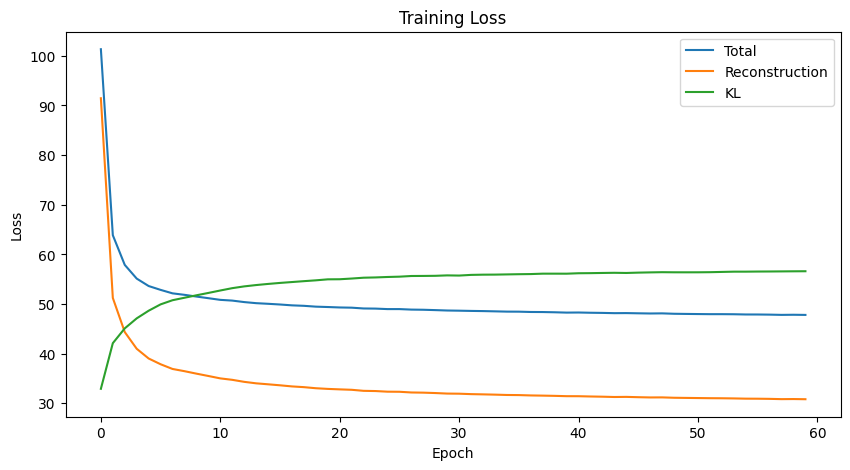

In [50]:
#plotting
plt.figure(figsize=(10,5))
plt.plot(train_losses, label="Total")
plt.plot(recon_losses, label="Reconstruction")
plt.plot(kl_losses, label="KL")
plt.legend()
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [51]:
torch.save(model.state_dict(), "m22aie202_vae_cifar.pth")

In [52]:
model.eval()

with torch.no_grad():
    z = torch.randn(16, latent_dim).to(device)
    samples = model.decoder(z).cpu()

In [53]:
grid = make_grid(samples, nrow=4)

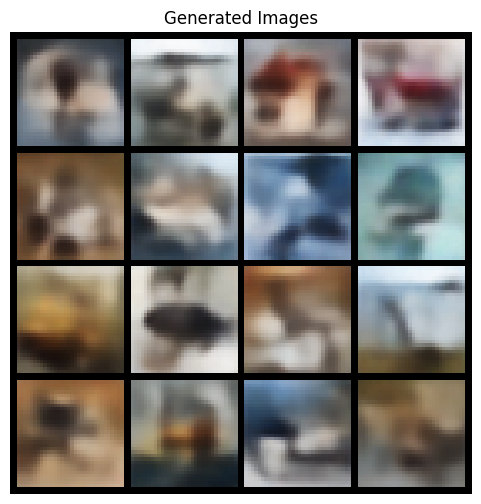

In [54]:
plt.figure(figsize=(6,6))
plt.imshow(np.transpose(grid, (1,2,0)))
plt.axis("off")
plt.title("Generated Images")
plt.show()